In [ ]:
import numpy as np

W, H = 500, 500
# Create 1D coordinate arrays
x = np.linspace(-20, 20, W)
y = np.linspace(-20, 20, H)
X, Y = np.meshgrid(x, y)



In [113]:
import numpy as np
from scipy.special import expit
def sigmoid(x, k=1.0):
    """
    Vectorized Sigmoid with adjustable slope k.
    x: NumPy array of any shape e.g. (500, 500)
    k: Steepness factor (float)
    """
    return expit(k * x)
def _get_2dsig(w,XY,k=1):
    w_nonlin = sigmoid(np.einsum('ijk,k->ij',XY,w),k=k)
    return w_nonlin
def get_dom(w1,w2,X,Y,k=1):
    XY = np.stack((X,Y),axis=-1)
    w1_nonlin = _get_2dsig(w1,XY,k=k)
    w2_nonlin = _get_2dsig(w2,XY,k=k)
    w12_nonlin = np.stack((w1_nonlin,w2_nonlin),axis=-1)
    dom = w12_nonlin.min(axis=2)
    return dom
def get_vordom(X,Y,k=1,is_inverse=False):
    thts = np.array([0,1,2])*np.pi*(2/3)
    if is_inverse:
        thts = - thts
    coss = np.cos(thts)
    sins = np.sin(thts)
    ws = np.stack((coss,sins),axis = 1)
    doms = []
    for ind,jnd in zip([0,1,2],[1,2,0]):
        doms.append(get_dom(ws[ind],-ws[jnd],X,Y,k=k))
    doms = foo = np.stack(doms,axis=2)
    return doms
def get_DWdom(tht,X,Y,k=1):
    XY = np.stack((X,Y),axis=-1)
    w = np.array((np.cos(tht),np.sin(tht)))
    dom = _get_2dsig(w,XY,k=k)
    doms = np.stack((dom,1-dom),axis = 2)
    return doms




In [84]:
import numpy as np
from matplotlib import pyplot as plt
def generate_triangular_lattice(H=500, W=500, spacing=30, sigma=2.5, amplitude=1.0, center=None):
    """
    Generate a triangular lattice pattern as a 2D numpy array.

    Parameters
    ----------
    H, W : int
        Height and width of the output array.
    spacing : float
        Distance between nearest lattice points (in pixels).
    sigma : float
        Gaussian peak width (standard deviation in pixels).
    amplitude : float
        Peak height.
    center : tuple(float, float) or None
        Center of the lattice in (x, y) pixel coordinates.
        Can be fractional (subpixel precision). If None, defaults to image center.

    Returns
    -------
    data : np.ndarray
        2D numpy array of shape (H, W) with normalized values in range [0, 1].
    """
    # Lattice basis vectors (triangular symmetry)
    a1 = np.array([1.0, 0.0])
    a2 = np.array([0.5, np.sqrt(3) / 2])

    # Coordinate grid
    y = np.arange(H)
    x = np.arange(W)
    X, Y = np.meshgrid(x, y)

    # Set center
    if center is None:
        center = (W / 2, H / 2)
    center = np.array(center, dtype=float)  # allow subpixel

    # Output array
    data = np.zeros((H, W), dtype=float)

    # Number of lattice points in each direction
    n_i = int(W / spacing) + 6
    n_j = int(H / spacing) + 6

    # Generate Gaussian peaks
    for i in range(-n_i, n_i + 1):
        for j in range(-n_j, n_j + 1):
            pos = (i * a1 + j * a2) * spacing + center
            px, py = pos
            # Skip points too far outside image
            if px < -3*sigma or px > W + 3*sigma or py < -3*sigma or py > H + 3*sigma:
                continue
            rr = (X - px) ** 2 + (Y - py) ** 2
            data += amplitude * np.exp(-rr / (2 * sigma ** 2))

    # Normalize to 0..1
    data = (data - data.min()) / (data.max() - data.min())

    return data
    

In [ ]:
import numpy as np

def get_angle_vector(angle_deg):
    theta = np.radians(angle_deg)
    return np.array([np.cos(theta), np.sin(theta)])
cs = get_angle_vector

r3 = np.sqrt(3)
spacing=30
sigma=15
posYinYangs = np.array(((0,0),
                        r3*30*cs(30)))
shifts = 15*r3*np.array((
    cs(210),
    cs(330),
    cs(90)
))*0.8

def base_lattice():
    img = np.zeros((H,W))
    center_offset = np.array((H,W))/2
    img += generate_triangular_lattice(H=H, W=W, spacing=spacing, sigma=sigma, center= (spacing/r3)*cs(30)+center_offset)
    img -= generate_triangular_lattice(H=H, W=W, spacing=spacing, sigma=sigma, center= (spacing/r3)*cs(-30)+center_offset)
    return img


def cdw(center_shift = (0,0)):
    img = np.zeros((H,W))
    center_offset = np.array((H,W))/2
    for iyy in range(2):
        posYinYang = posYinYangs[iyy] 
        for ishift in range(3):
            shift = shifts[ishift]
            center = posYinYang + shift * (-2*iyy+1) + center_shift + center_offset #+ 30*cs(120)*i4             
            corrugation_now = generate_triangular_lattice(H=H, W=W, spacing=spacing*3, sigma=sigma,  center=center)*.5
            img += corrugation_now* (-2*iyy+1)
    return img

In [125]:
# img = base_lattice() + cdw(0)*2
latt = base_lattice()
# cdw0 = cdw(0)*2
cdw1 = cdw(30*cs(120))
cdw0 = cdw(30*cs(60))
cdw00 = cdw(0)


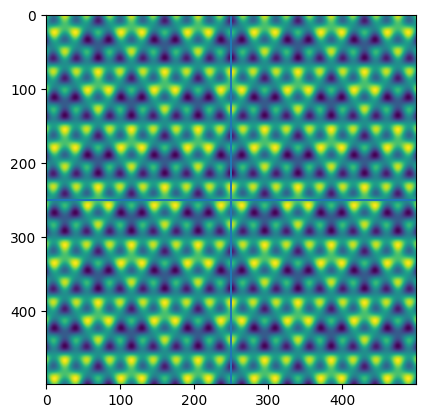

In [126]:
plt.imshow(latt+cdw00)
plt.axhline(H/2)
plt.axvline(W/2)

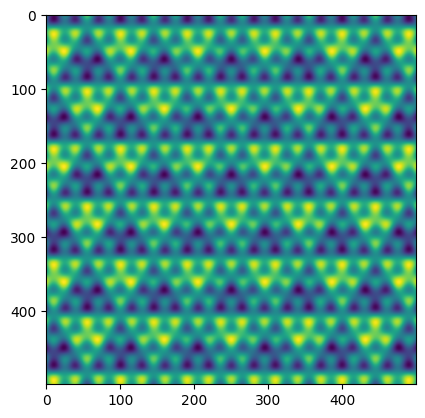

In [130]:
doms = get_DWdom(0,X,Y,k=.1)
fin = latt + cdw0*doms[:,:,0]*2+cdw1*doms[:,:,1]*2
plt.imshow(fin)